In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..', '..')))

import argparse
from pprint import pp
import torch
from torch import nn
from tqdm import tqdm
import numpy as np
import json
import os
from omegaconf import OmegaConf
from torch.utils.tensorboard import SummaryWriter

from lpn.utils import load_dataset, load_config
from lpn.utils import get_model
from lpn.utils import get_loss_hparams_and_lr, get_loss
from lpn.utils import trainer
from lpn.utils import utils
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
lpn_model_config_path = os.path.join('..','models','lpn','s=0.1','model_config.json')
lpn_model_weight_path = os.path.join('..','models','lpn','s=0.1','model.pt')

lpn_model_config = load_config(lpn_model_config_path)
lpn_model = get_model(lpn_model_config)
lpn_model.load_state_dict(torch.load(lpn_model_weight_path)['model_state_dict'])
lpn_model.to(device)

init weights


LPN(
  (lin): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (6): Conv2d(256, 64, kernel_size=(16, 16), stride=(1, 1), bias=False)
    (7): Linear(in_features=64, out_features=1, bias=True)
  )
  (res): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 

In [4]:
# The NE LPN model by the forward normalization trick
ne_lpn_by_forward_model_config_path = '../models/ne_by_forward_lpn/s=0.1/model_config.json'
ne_lpn_by_forward_model_weight_path = '../models/ne_by_forward_lpn/s=0.1/model.pt'
ne_lpn_by_forward_model_config = load_config(ne_lpn_by_forward_model_config_path)
ne_lpn_by_forward_model = get_model(ne_lpn_by_forward_model_config)
ne_lpn_by_forward_model.load_state_dict(torch.load(ne_lpn_by_forward_model_weight_path)['model_state_dict'])
ne_lpn_by_forward_model.to(device)

init weights


LPN(
  (lin): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (6): Conv2d(256, 64, kernel_size=(16, 16), stride=(1, 1), bias=False)
    (7): Linear(in_features=64, out_features=1, bias=True)
  )
  (res): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 

In [5]:
# Scale-Equivariant By Design LPN

scale_eq_lpn_by_design_config_path = os.path.join('..','models','scale_equiv_lpn','s=0.1','model_config.json')
scale_eq_lpn_by_design_weight_path = os.path.join('..','models','scale_equiv_lpn','s=0.1','model.pt')
scale_eq_lpn_by_design_config = load_config(scale_eq_lpn_by_design_config_path)
scale_eq_lpn_by_design_model = get_model(scale_eq_lpn_by_design_config)
scale_eq_lpn_by_design_model.load_state_dict(torch.load(scale_eq_lpn_by_design_weight_path)['model_state_dict'])
scale_eq_lpn_by_design_model.to(device)

init weights


LPN(
  (lin): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (6): Conv2d(256, 64, kernel_size=(16, 16), stride=(1, 1), bias=False)
    (7): Linear(in_features=64, out_features=1, bias=False)
  )
  (res): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (2): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (3): Conv2d(3, 256

In [18]:
# Shift-Equivariant By Design LPN
shift_eq_lpn_by_design_config_path = os.path.join('..','models','shift_equiv_lpn','s=0.1','model_config.json')
shift_eq_lpn_by_design_weight_path = os.path.join('..','models','shift_equiv_lpn','s=0.1','model.pt')
shift_eq_lpn_by_design_config = load_config(shift_eq_lpn_by_design_config_path)
shift_eq_lpn_by_design_model = get_model(shift_eq_lpn_by_design_config)
shift_eq_lpn_by_design_model.load_state_dict(torch.load(shift_eq_lpn_by_design_weight_path)['model_state_dict'])
shift_eq_lpn_by_design_model.to(device)

init weights


LPN(
  (lin): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (6): Conv2d(256, 64, kernel_size=(16, 16), stride=(1, 1), bias=False)
    (7): Linear(in_features=64, out_features=1, bias=True)
  )
  (res): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 

In [6]:
# NE-LPN by Design (with SortPool activation)

ne_by_design_lpn_model_config_path = os.path.join('..','models','ne_by_design_lpn','s=0.1','model_config.json')
ne_by_design_lpn_model_weight_path = os.path.join('..','models','ne_by_design_lpn','s=0.1','model.pt')
ne_by_design_lpn_model_config = load_config(ne_by_design_lpn_model_config_path)
ne_by_design_lpn_model = get_model(ne_by_design_lpn_model_config)
ne_by_design_lpn_model.load_state_dict(torch.load(ne_by_design_lpn_model_weight_path)['model_state_dict'])
ne_by_design_lpn_model.to(device)


init weights


LPN(
  (lin): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (6): Conv2d(256, 64, kernel_size=(16, 16), stride=(1, 1), bias=False)
    (7): Linear(in_features=64, out_features=1, bias=False)
  )
  (res): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (2): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (3): Conv2d(3, 256

In [ ]:
dataset_config_path = os.path.join('..','configs','dataset.json')
dataset_config = load_config(dataset_config_path)
dataset_config['params']['root'] = '../../../data/bsds500'
test_dataset = load_dataset(dataset_config, 'test')
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=4)

dataset:  bsds500


In [8]:
def visualize_dataloader(dataloader):
    for i, data in enumerate(dataloader):
        image = data['image'].squeeze(0).permute(1, 2, 0).cpu().numpy()
        plt.imshow(image)
        plt.show()
        if i == 5:
            break
#visualize_dataloader(test_dataloader)  #uncomment to visualize

In [9]:
noise_levels = [0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7]

In [10]:
from skimage.metrics import peak_signal_noise_ratio as skimage_psnr
from skimage.metrics import structural_similarity as skimage_ssim
from collections import defaultdict

def evaluate_model(model, dataloader, noise_levels):
    """
    Evaluate the model on the given dataloader for different noise levels.
    Returns:
    - avg_psnr_list: List of average PSNR values for each noise level.
    - avg_ssim_list: List of average SSIM values for each noise level.
    - sd_psnr_list: List of standard deviation of PSNR values for each noise level
    - sd_ssim_list: List of standard deviation of SSIM values for each noise level
    - img_dict: Dictionary with noise levels as keys and list of tuples (ground truth,
      denoised) images as values.
    """
    model.eval()
    avg_psnr_list = []
    avg_ssim_list = []
    sd_psnr_list = []
    sd_ssim_list = []
    img_dict = defaultdict(list)

    for noise in tqdm(noise_levels, total=len(noise_levels)):
        psnr_list = []
        ssim_list = []
        for i, data in tqdm(enumerate(dataloader), total=len(dataloader)):
            img = data['image'].to(device)
            noise_tensor = torch.randn_like(img) * noise
            noisy_img = img + noise_tensor

            with torch.no_grad():
                denoised_img = model(noisy_img)

            img_np = img.squeeze(0).permute(1, 2, 0).cpu().detach().numpy() 
            denoised_np = denoised_img.squeeze(0).permute(1, 2, 0).cpu().detach().numpy()
            img_dict[noise].append((img_np, denoised_np)) # (ground truth, denoised)

            psnr = skimage_psnr(img_np, denoised_np, data_range=1.0)
            ssim = skimage_ssim(img_np, denoised_np, data_range=1.0, channel_axis=-1)

            psnr_list.append(psnr)
            ssim_list.append(ssim)
        avg_psnr = np.mean(psnr_list)
        avg_ssim = np.mean(ssim_list)
        sd_psnr = np.std(psnr_list)
        sd_ssim = np.std(ssim_list)
        avg_psnr_list.append(avg_psnr)
        avg_ssim_list.append(avg_ssim)
        sd_psnr_list.append(sd_psnr)
        sd_ssim_list.append(sd_ssim)
        print(f"Average PSNR for noise level {noise}: {avg_psnr:.2f}")
        print(f"Average SSIM for noise level {noise}: {avg_ssim:.4f}")
    return avg_psnr_list, avg_ssim_list, sd_psnr_list, sd_ssim_list, img_dict


In [11]:
import imageio.v2 as imageio

def save_images(img_dict, save_dir="../results/denoised_images"):
    os.makedirs(save_dir, exist_ok=True)

    for noise, img_pairs in img_dict.items():
        noise_dir = os.path.join(save_dir, f"noise_{noise}")
        os.makedirs(noise_dir, exist_ok=True)

        for idx, (gt, denoised) in enumerate(img_pairs):
            gt_path = os.path.join(noise_dir, f"gt_{idx}.png")
            denoised_path = os.path.join(noise_dir, f"denoised_{idx}.png")

            gt_uint8 = (np.clip(gt, 0, 1) * 255).astype(np.uint8)
            denoised_uint8 = (np.clip(denoised, 0, 1) * 255).astype(np.uint8)

            imageio.imwrite(gt_path, gt_uint8)
            imageio.imwrite(denoised_path, denoised_uint8)


In [12]:
save_dir = '../denoising_results'
os.makedirs(save_dir, exist_ok=True)

In [13]:
lpn_psnr, lpn_ssim, lpn_sd_psnr, lpn_sd_ssim, lpn_img_dict = evaluate_model(lpn_model, test_dataloader, noise_levels)
np.savez(
    "../denoising_results/bsd_lpn_results.npz",
    noise_levels=np.array(noise_levels, dtype=float),
    psnr=np.array(lpn_psnr, dtype=float),
    ssim=np.array(lpn_ssim, dtype=float),
    sd_psnr=np.array(lpn_sd_psnr, dtype=float),
    sd_ssim=np.array(lpn_sd_ssim, dtype=float),
    model_name="LPN",
)
save_images(lpn_img_dict, save_dir="../denoising_results/denoised_images/lpn")

 12%|█▎        | 1/8 [00:04<00:29,  4.24s/it]

Average PSNR for noise level 0.05: 31.20
Average SSIM for noise level 0.05: 0.8825


 25%|██▌       | 2/8 [00:06<00:19,  3.27s/it]

Average PSNR for noise level 0.1: 29.55
Average SSIM for noise level 0.1: 0.8598


 38%|███▊      | 3/8 [00:09<00:14,  2.96s/it]

...

Average PSNR for noise level 0.5: 5.28
Average SSIM for noise level 0.5: 0.0823


 88%|████████▊ | 7/8 [00:19<00:02,  2.66s/it]

Average PSNR for noise level 0.6: 1.56
Average SSIM for noise level 0.6: 0.0411


100%|██████████| 8/8 [00:22<00:00,  2.83s/it]


Average PSNR for noise level 0.7: -1.38
Average SSIM for noise level 0.7: 0.0187


In [14]:
ne_by_forward_psnr, ne_by_forward_ssim, ne_by_forward_sd_psnr, ne_by_forward_sd_ssim, ne_by_forward_img_dict = evaluate_model(ne_lpn_by_forward_model, test_dataloader, noise_levels)
np.savez(
    "../denoising_results/bsd_ne_by_forward_lpn_results.npz",
    noise_levels=np.array(noise_levels, dtype=float),
    psnr=np.array(ne_by_forward_psnr, dtype=float),
    ssim=np.array(ne_by_forward_ssim, dtype=float),
    sd_psnr=np.array(ne_by_forward_sd_psnr, dtype=float),
    sd_ssim=np.array(ne_by_forward_sd_ssim, dtype=float),
    model_name="NE-LPN (By Normalization Trick)",
)
save_images(ne_by_forward_img_dict, save_dir="../denoising_results/denoised_images/ne_by_forward_lpn")

 12%|█▎        | 1/8 [00:02<00:18,  2.62s/it]

Average PSNR for noise level 0.05: 31.02
Average SSIM for noise level 0.05: 0.8857


 25%|██▌       | 2/8 [00:05<00:15,  2.63s/it]

Average PSNR for noise level 0.1: 29.09
Average SSIM for noise level 0.1: 0.8441


 38%|███▊      | 3/8 [00:07<00:13,  2.67s/it]

...

Average PSNR for noise level 0.5: 17.25
Average SSIM for noise level 0.5: 0.3346


 88%|████████▊ | 7/8 [00:18<00:02,  2.59s/it]

Average PSNR for noise level 0.6: 15.77
Average SSIM for noise level 0.6: 0.2782


100%|██████████| 8/8 [00:20<00:00,  2.62s/it]


Average PSNR for noise level 0.7: 14.54
Average SSIM for noise level 0.7: 0.2349


In [15]:
scale_by_design_psnr, scale_by_design_ssim, scale_by_design_sd_psnr, scale_by_design_sd_ssim, scale_by_design_img_dict = evaluate_model(scale_eq_lpn_by_design_model, test_dataloader, noise_levels)
np.savez(
    "../denoising_results/bsd_scale_eq_by_design_lpn_results.npz",
    noise_levels=np.array(noise_levels, dtype=float),
    psnr=np.array(scale_by_design_psnr, dtype=float),
    ssim=np.array(scale_by_design_ssim, dtype=float),
    sd_psnr=np.array(scale_by_design_sd_psnr, dtype=float),
    sd_ssim=np.array(scale_by_design_sd_ssim, dtype=float),
    model_name="Scale-Equivariant LPN (By Design)",
)
save_images(scale_by_design_img_dict, save_dir="../denoising_results/denoised_images/scale_eq_by_design_lpn")

 12%|█▎        | 1/8 [00:02<00:19,  2.85s/it]

Average PSNR for noise level 0.05: 17.06
Average SSIM for noise level 0.05: 0.5177


 25%|██▌       | 2/8 [00:05<00:16,  2.80s/it]

Average PSNR for noise level 0.1: 17.14
Average SSIM for noise level 0.1: 0.5043


 38%|███▊      | 3/8 [00:08<00:14,  2.86s/it]

...

Average PSNR for noise level 0.5: 14.28
Average SSIM for noise level 0.5: 0.2292


 88%|████████▊ | 7/8 [00:20<00:02,  2.95s/it]

Average PSNR for noise level 0.6: 13.23
Average SSIM for noise level 0.6: 0.1869


100%|██████████| 8/8 [00:23<00:00,  2.94s/it]


Average PSNR for noise level 0.7: 12.27
Average SSIM for noise level 0.7: 0.1544


In [19]:
shift_eq_by_design_psnr, shift_eq_by_design_ssim, shift_eq_by_design_sd_psnr, shift_eq_by_design_sd_ssim, shift_eq_by_design_img_dict = evaluate_model(shift_eq_lpn_by_design_model, test_dataloader, noise_levels)
np.savez(
    "../denoising_results/bsd_shift_eq_by_design_lpn_results.npz",
    noise_levels=np.array(noise_levels, dtype=float),
    psnr=np.array(shift_eq_by_design_psnr, dtype=float),
    ssim=np.array(shift_eq_by_design_ssim, dtype=float),
    sd_psnr=np.array(shift_eq_by_design_sd_psnr, dtype=float),
    sd_ssim=np.array(shift_eq_by_design_sd_ssim, dtype=float),
    model_name="Shift-Equivariant LPN (By Design)",
)
save_images(shift_eq_by_design_img_dict, save_dir="../denoising_results/denoised_images/shift_eq_by_design_lpn")

 12%|█▎        | 1/8 [00:02<00:20,  2.90s/it]

Average PSNR for noise level 0.05: 30.69
Average SSIM for noise level 0.05: 0.8719


 25%|██▌       | 2/8 [00:05<00:16,  2.79s/it]

Average PSNR for noise level 0.1: 29.14
Average SSIM for noise level 0.1: 0.8516


 38%|███▊      | 3/8 [00:08<00:14,  2.82s/it]

...

Average PSNR for noise level 0.5: 7.10
Average SSIM for noise level 0.5: 0.0955


 88%|████████▊ | 7/8 [00:20<00:02,  2.92s/it]

Average PSNR for noise level 0.6: 4.87
Average SSIM for noise level 0.6: 0.0644


100%|██████████| 8/8 [00:23<00:00,  2.89s/it]


Average PSNR for noise level 0.7: 3.26
Average SSIM for noise level 0.7: 0.0469


In [16]:
ne_by_design_lpn_psnr, ne_by_design_lpn_ssim, ne_by_design_lpn_sd_psnr, ne_by_design_lpn_sd_ssim, ne_by_design_lpn_img_dict = evaluate_model(ne_by_design_lpn_model, test_dataloader, noise_levels)
np.savez(
    "../denoising_results/bsd_ne_by_design_lpn_results.npz",
    noise_levels=np.array(noise_levels, dtype=float),
    psnr=np.array(ne_by_design_lpn_psnr, dtype=float),
    ssim=np.array(ne_by_design_lpn_ssim, dtype=float),
    sd_psnr=np.array(ne_by_design_lpn_sd_psnr, dtype=float),
    sd_ssim=np.array(ne_by_design_lpn_sd_ssim, dtype=float),
    model_name="NE-LPN (By Design)",
)
save_images(ne_by_design_lpn_img_dict, save_dir="../denoising_results/denoised_images/ne_by_design_lpn")

 12%|█▎        | 1/8 [00:02<00:20,  2.95s/it]

Average PSNR for noise level 0.05: 23.83
Average SSIM for noise level 0.05: 0.7714


 25%|██▌       | 2/8 [00:06<00:18,  3.10s/it]

Average PSNR for noise level 0.1: 23.55
Average SSIM for noise level 0.1: 0.7269


 38%|███▊      | 3/8 [00:09<00:15,  3.18s/it]

...

Average PSNR for noise level 0.5: 17.04
Average SSIM for noise level 0.5: 0.3134


 88%|████████▊ | 7/8 [00:22<00:03,  3.16s/it]

Average PSNR for noise level 0.6: 15.66
Average SSIM for noise level 0.6: 0.2596


100%|██████████| 8/8 [00:25<00:00,  3.18s/it]


Average PSNR for noise level 0.7: 14.45
Average SSIM for noise level 0.7: 0.2181


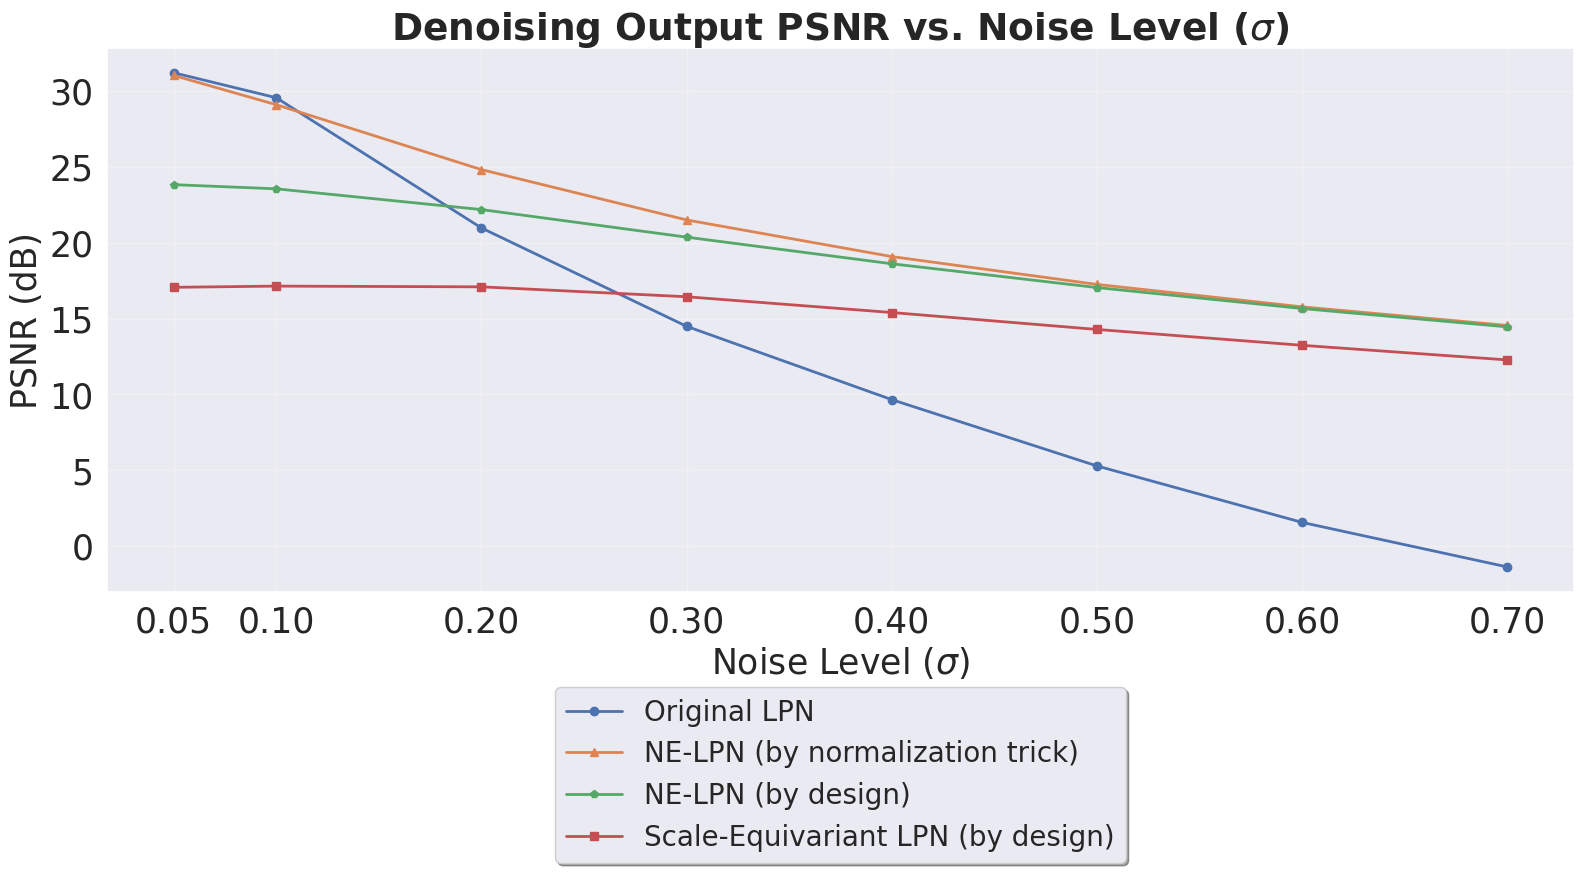

In [17]:
plt.figure(figsize=(16, 8))
plt.plot(noise_levels, lpn_psnr, label='Original LPN', linewidth=2, marker='o')
plt.plot(noise_levels, ne_by_forward_psnr, label='NE-LPN (by normalization trick)', linewidth=2, marker='^')
plt.plot(noise_levels, ne_by_design_lpn_psnr, label='NE-LPN (by design)', linewidth=2, marker='p')
plt.plot(noise_levels, scale_by_design_psnr, label="Scale-Equivariant LPN (by design)", linewidth=2, marker='s')

# Larger axis labels and title
plt.xlabel(r'Noise Level ($\sigma$)', fontsize=25)
plt.ylabel(r'PSNR (dB)', fontsize=25)
plt.title(r'Denoising Output PSNR vs. Noise Level ($\sigma$)', 
          fontsize=27, fontweight='bold')

# Larger tick labels
plt.xticks(noise_levels, fontsize=25)
plt.yticks(fontsize=25)

# Grid
plt.grid(True, alpha=0.3)

# Bigger, clearer legend
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), 
           ncol=1, fontsize=20, frameon=True, fancybox=True, shadow=True)

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)

plt.show()
